Here, we ensure that the bias alone (which contains categorical information) and the RNN alone (whichc contains stimulation information) do not suffice for good predictions. 

In [54]:
import os
import json 

import pandas as pd
import scanpy as sc
import numpy as np

import torch
from geomloss import SamplesLoss
import gc


import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io

sys.path.insert(1, '../.')
from Kang_utils import stim_map, rev_stim_map, rev_stim, get_best_hyperparams

In [3]:
seed = 888
device = "cuda" if torch.cuda.is_available() else "cpu"

author = 'Kang'
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
models_path = os.path.join(data_path, 'processed', 'models')

In [4]:
n_cores = 20
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

In [5]:
tf_adata = io.read_tfad(os.path.join(data_path, 'processed', 'Kang_tf_activity.h5ad'))
tf_adata.obs['condition'] = tf_adata.obs['stim'].astype(str) + '^' + tf_adata.obs['seurat_annotations'].astype(str)

adata = sc.read_h5ad(os.path.join(data_path, 'processed', 'kang_expr_scored.h5ad'))
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_sn_ppis.csv'), index_col = 0)

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

In [7]:
res = pd.read_csv(os.path.join(data_path, 'processed', 'Kang_k_fold_validation_results.csv'), index_col = 0)
best_emd_mean, best_hyperparams, best_emd = get_best_hyperparams(res)
trainers_best = {k: io.read_pickled_object(os.path.join(models_path, 'Kang_best_trainer_' + str(k) + '.pickle')) for k in range(best_emd.shape[0])}
trainers_best['all'] = io.read_pickled_object(os.path.join(data_path, 'processed', 'Kang_fullbest_trainer.pickle'))

test_cells = open(os.path.join(data_path, 'processed', 'data_split_barcodes', 'kang_test.txt')).read().splitlines()
test_conds = sorted(tf_adata.obs.loc[test_cells, 'condition'].unique())


In [66]:
from typing import Literal
def forward_nobias(mod, X_in, covariates_idx, expr, 
                  remove: Literal['all', 'global', 'categorical'] = 'all'):
    """Sets bias term to zero in forward pass"""
    mod.eval()
    with torch.inference_mode():
        X_full = mod.input_layer(X_in) # input ligands to signaling network
        
        if remove == 'all':
            bias_tot = torch.zeros_like(X_full.T, device = mod.signaling_network.device, dtype = mod.signaling_network.dtype)
        elif remove == 'global':
            bias_cats = torch.zeros_like(X_full.T, device = mod.signaling_network.device, dtype = mod.signaling_network.dtype)
            # add categorical covariates
            for cat_group_idx in range(covariates_idx.shape[1]):
                cat_group = mod.signaling_network._cat_group_idx[cat_group_idx]
                bias_cats += mod.signaling_network.cat_embeddings[cat_group](covariates_idx[:,cat_group_idx]).T
            bias_tot = bias_cats
        elif remove == 'categorical':
            bias_mu, bias_log_sigma_squared, bias_global = mod.signaling_network.vae(expr)
            bias_global.data.masked_fill_(mask = mod.signaling_network.bias_mask.T.expand(bias_global.shape[0], -1), value = 0.0) # apply bias mask
            bias_tot = bias_global.T

        X_bias = X_full.T + bias_tot
        X_new = torch.zeros_like(X_bias) #initialize hidden state values at 0
        for t in range(mod.signaling_network.bionet_params['max_steps']): # like an RNN, updating from previous time step
            X_old = X_new
            X_new = torch.mm(mod.signaling_network.weights, X_new) # scale matrix by edge weights
            X_new = X_new + X_bias  # add original values and bias       
            X_new = mod.signaling_network.activation(X_new, mod.signaling_network.bionet_params['leak'])

            if (t % 10 == 0) and (t > 20):
                diff = torch.max(torch.abs(X_new - X_old))    
                if diff.lt(mod.signaling_network.bionet_params['tolerance']):
                    break
        Y_full = X_new.T

        Y_hat = mod.output_layer(Y_full)
        
    del Y_full, bias_tot, X_bias, X_new, X_old 
    del X_in, covariates_idx, expr
    if remove == 'global':
        del bias_cats
    elif remove == 'categorical':
        del bias_mu, bias_log_sigma_squared, bias_global
        
    torch.cuda.empty_cache() 
    gc.collect()
    
    return Y_hat


def forward_noadj(mod, X_in, covariates_idx, expr):
    """Sets signaling network weights to 0 during forward pass"""
    X_full = mod.input_layer(X_in) 

    bias_cats = torch.zeros_like(X_full.T, device = mod.signaling_network.device, dtype = mod.signaling_network.dtype)
    for cat_group_idx in range(covariates_idx.shape[1]):
        cat_group = mod.signaling_network._cat_group_idx[cat_group_idx]
        bias_cats += mod.signaling_network.cat_embeddings[cat_group](covariates_idx[:,cat_group_idx]).T
    bias_mu, bias_log_sigma_squared, bias_global = mod.signaling_network.vae(expr)
    bias_global.data.masked_fill_(mask = mod.signaling_network.bias_mask.T.expand(bias_global.shape[0], -1), value = 0.0) # apply bias mask
    bias_tot = bias_global.T + bias_cats

    X_bias = X_full.T + bias_tot
    X_new = torch.zeros_like(X_bias) #initialize hidden state values at 0
    for t in range(mod.signaling_network.bionet_params['max_steps']): # like an RNN, updating from previous time step
        X_old = X_new
        X_new = torch.mm(torch.zeros(mod.signaling_network.weights.shape, 
                                     device = mod.signaling_network.device, 
                                    requires_grad=False), 
                         X_new) # scale matrix by edge weights
        X_new = X_new + X_bias  # add original values and bias       
        X_new = mod.signaling_network.activation(X_new, mod.signaling_network.bionet_params['leak'])

    Y_full = X_new.T

    Y_hat = mod.output_layer(Y_full)
    
    del Y_full, bias_cats, bias_mu, bias_log_sigma_squared, bias_global, bias_tot, X_bias, X_new, X_old
    del X_in, covariates_idx, expr
    torch.cuda.empty_cache() 
    gc.collect()
    return Y_hat


In [84]:
torch.zeros(3,2, requires_grad = False)

tensor([[0., 0.],
        [0., 0.],
        [0., 0.]])

In [67]:
res_all = dict(zip(['in_distribution', 'opposite'],[[], []]))

for k, trainer_k in trainers_best.items():
    mod = trainer_k.mod
    train_cells_all = trainer_k.X_train.index.tolist()

    cf_map = {'in_distribution': train_cells_all}
#     counterfactual_type = 'opposite'
    for counterfactual_type in ['in_distribution', 'opposite']:
        cov_idx_map = dict(zip(mod.signaling_network.covariates['seurat_annotations'], 
                               mod.signaling_network.covariates_idx['seurat_annotations']))

        tot_loss_actual, tot_loss_noadj = 0,0
        tot_loss_nobias = {'all': 0, 'categorical': 0, 'global': 0}

        for cond in test_conds:
            stim, ct = cond.split('^')
            test_cells_cond = tf_adata.obs[(tf_adata.obs.index.isin(test_cells)) & (tf_adata.obs['condition'] == cond)].index.tolist()
            y_test = mod.df_to_tensor(tf_adata.to_df().loc[test_cells_cond, :])


            if counterfactual_type == 'opposite':
                train_cells_cond = tf_adata.obs[(tf_adata.obs['condition'] == rev_stim[stim] + '^' + ct)].index.tolist()
                if len(set(train_cells_cond).difference(train_cells_all)) != 0:
                    raise ValueError('Something went wrong in the counterfactual')
            else:
                train_cells_cond = cf_map[counterfactual_type]

            expr_test = mod.df_to_tensor(mod.expr.loc[train_cells_cond, :])

            X_test_df = pd.DataFrame(data = {'IFNB1': [stim_map[stim]]*len(train_cells_cond)})
            X_test = mod.df_to_tensor(X_test_df)

            covariates_idx_test = torch.tensor([cov_idx_map[ct]]*len(train_cells_cond), 
                                               device = mod.device, dtype = torch.int64).view(-1,1)


            # actual
            mod.eval()
            with torch.inference_mode():
                y_predicted_actual, _, _ = mod(X_in = X_test, covariates_idx = covariates_idx_test, expr = expr_test)
            loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
            tot_loss_actual += loss_fn(y_predicted_actual, y_test).detach().cpu().item()
            del y_predicted_actual, _
            torch.cuda.empty_cache() 
            gc.collect()

            # removing bias
            for remove_type in tot_loss_nobias:
                y_predicted_nobias = forward_nobias(mod, 
                                                     X_in = X_test, 
                                                     covariates_idx = covariates_idx_test, 
                                                     expr = expr_test, 
                                                    remove = remove_type)

                loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
                tot_loss_nobias[remove_type] += loss_fn(y_predicted_nobias, y_test).detach().cpu().item()
                del y_predicted_nobias
                torch.cuda.empty_cache() 
                gc.collect()

            # removing adjacency matrix
            y_predicted_noadj = forward_noadj(mod, 
                                                    X_in = X_test, 
                                                    covariates_idx = covariates_idx_test, 
                                                    expr = expr_test)
            loss_fn = SamplesLoss("sinkhorn", p=2, blur=0.05).to(device)
            tot_loss_noadj += loss_fn(y_predicted_noadj, y_test).detach().cpu().item()
            del y_predicted_noadj
            torch.cuda.empty_cache() 
            gc.collect()

        tot_losses = {**{'fold': k,
                  'actual': tot_loss_actual, 
                 'noadj': tot_loss_noadj}, 
                  **{'bias_' + key:v for key, v in tot_loss_nobias.items()}}
        res_all[counterfactual_type].append(tot_losses)
        with open(os.path.join(data_path, 'processed', author + '_remove_components.json'), 'w') as json_file:
            json.dump(res_all, json_file, indent=4)



/tmp/ipykernel_1181066/648148612.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


''

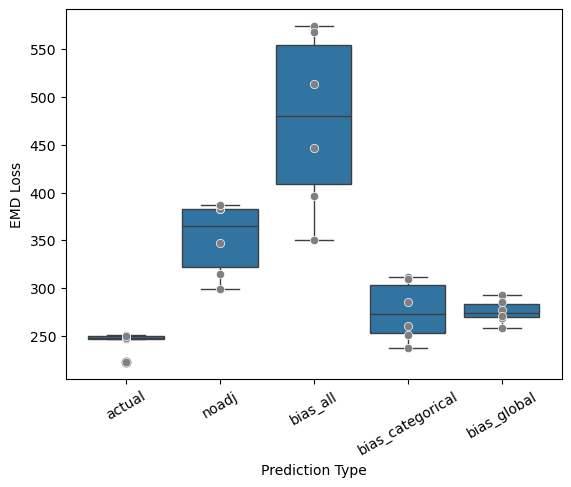

In [82]:
fig, ax = plt.subplots()

viz_df = pd.DataFrame(res_all[counterfactual_type])
viz_df = viz_df.melt(id_vars='fold', var_name='Prediction Type', value_name='EMD Loss')
sns.boxplot(data = viz_df, x = 'Prediction Type', y = 'EMD Loss', ax = ax, zorder = 0)
sns.scatterplot(data = viz_df, x = 'Prediction Type', y = 'EMD Loss', color = 'gray', ax = ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
;